In [290]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import numpy as np
from scipy import linalg as la
from matplotlib import pyplot as plt
import matplotlib

import adaptive

from tai_localiser.lauralizer import amorphous_model_BHZ_2D as am
from tai_localiser.lauralizer.amorphous_model_BHZ_2D import amorph_BHZ, zero_params
from tai_localiser.lauralizer.localizer import (
    spectral_localizer_AII2D,
    pfaff_sign,
    local_gap_localizer,
)
from tai_localiser.perulizer import proximity_lattice, proximity_bonds

from koala.lattice import Lattice
from koala import pointsets
from koala import plotting as pl
import kwant as k

# local imports
from func_for_fig2 import param_obs_2b

adaptive.notebook_extension()

ImportError: cannot import name 'zero_params' from 'tai_localiser.lauralizer.amorphous_model_BHZ_2D' (/Users/laura/Desktop/TAI-localizer/src/tai_localiser/lauralizer/amorphous_model_BHZ_2D.py)

In [292]:
matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [293]:
# lattice parameters
system_size = 10
bond_lengthscale = 1 / system_size
bond_distance = 1.3 / system_size
beta = 1
sigma_bounds = (0.0, 0.2 / system_size)
kappa_shift = 0

# model parameters
A = 1.0
B = 1.0
delta = 2.0
delta_bounds = (-2, 4)
alpha = 0.0
onsite_disorder = 0
disorder_bounds = (0, 15)
hadamard_disorder = 0.15
bond_power = 2

# localiser parameter
kappa = 1

# run parameters
disorder_averages = 50
n_task = 8


load = False
save = False


def goal(l):
    # return l.loss() < 0.05  # continue until loss is small enough
    return l.npoints > 1000  # continue until 1000 points


fname = "results/fig_2_"

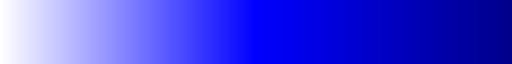

In [294]:
colors = ["w", "b", "darkblue"]

# Create a list of positions for each color in the colormap:
positions = [0.0, 0.5, 1.0]

# Create a LinearSegmentedColormap (continuous colors):
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "custom_colormap", list(zip(positions, colors))
)
custom_cmap

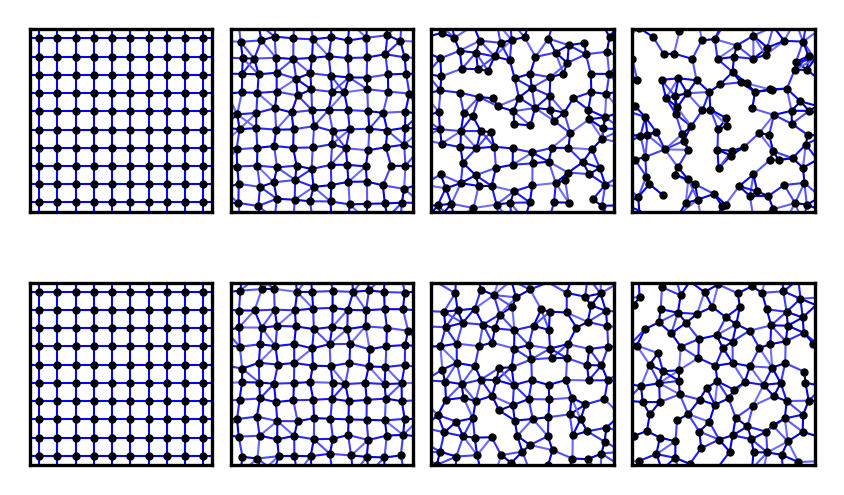

In [295]:
# lets add a check of the graphs that we want to generate
n_points = 5
row = 4
initial_points = pointsets.grid(system_size, system_size)

fig, ax = plt.subplots(
    2 * n_points // row,
    row,
    figsize=(aps_halfwidth, 2.3 * (n_points // row) * aps_halfwidth / row),
    dpi=300,
)

sigmas = np.linspace(sigma_bounds[0], sigma_bounds[1] * 2, n_points)

for a in ax.flatten():
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")


for a, sigma in zip(ax[0, :], sigmas):

    p = pointsets.move_all_points(initial_points, sigma, kappa_shift, beta)

    a.scatter(*p.T, s=1, color="black")
    lat = proximity_lattice(p, bond_distance)

    rhos = la.norm(lat.edges.vectors, axis=1)
    rescaled_distances = (rhos - bond_lengthscale) / bond_lengthscale
    hopping_multiplier = np.exp(-rescaled_distances * bond_power)
    hopping_capped = np.clip(hopping_multiplier, 0, 1)

    colours = custom_cmap(hopping_multiplier / 2)
    indices = np.arange(lat.n_edges)

    pl.plot_edges(
        lat, ax=a, color_scheme=colours, labels=indices, linewidth=0.5, zorder=-1
    )

for a, sigma in zip(ax[1, :], sigmas):
    p = pointsets.move_all_points(initial_points, sigma, 0.3, 1)

    a.scatter(*p.T, s=1, color="black")
    lat = proximity_lattice(p, bond_distance)

    rhos = la.norm(lat.edges.vectors, axis=1)
    rescaled_distances = (rhos - bond_lengthscale) / bond_lengthscale
    hopping_multiplier = np.exp(-rescaled_distances * bond_power)

    colours = custom_cmap(hopping_multiplier / 2)
    indices = np.arange(lat.n_edges)
    pl.plot_edges(
        lat, ax=a, color_scheme=colours, labels=indices, linewidth=0.5, zorder=-1
    )

fig.subplots_adjust(hspace=0.3, wspace=0.1)
plt.savefig("lattice_fig.pdf", transparent=True)
plt.show()

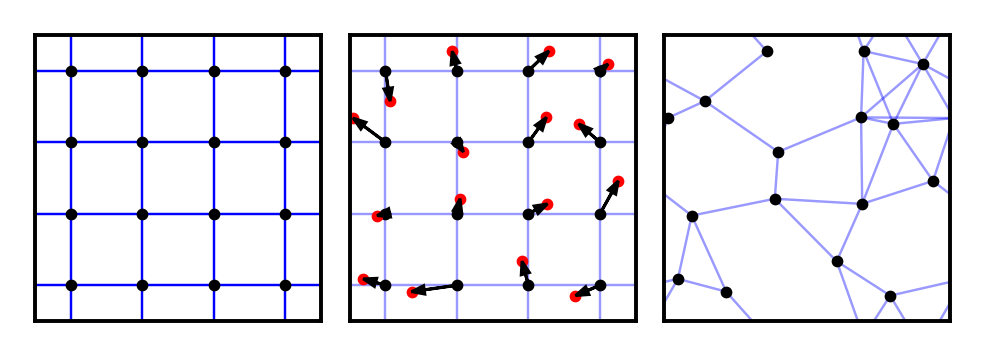

In [327]:
N = 4
fig, ax = plt.subplots(
    1,
    3,
    figsize=(aps_halfwidth, 1.3 * (n_points // row) * aps_halfwidth / row),
    dpi=350,
)
for a in ax.flatten():
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")

# initial_points = pointsets.grid(N, N)
# lat1 = proximity_lattice(initial_points, 1.3 / N)
# p = pointsets.move_all_points(initial_points, 0.07, 0.3, 1)
# lat2 = proximity_lattice(p, 1.3 / N)


ax[0].scatter(*initial_points.T, s=2, color="black")
pl.plot_edges(lat1, ax=ax[0], color="b", linewidth=0.5, zorder=-1)
pl.plot_edges(lat1, ax=ax[1], color="b", linewidth=0.5, zorder=-1, alpha=0.4)
pl.plot_edges(lat2, ax=ax[2], color="b", linewidth=0.5, zorder=-1, alpha=0.4)


ax[1].scatter(*initial_points.T, s=2, color="black")
ax[1].scatter(*p.T, s=2, color="red")
ax[2].scatter(*p.T, s=2, color="k")

for j in range(len(p)):
    p1 = initial_points[j]
    p2 = p[j]
    shifts = p2 - p1
    shifts = (shifts + 0.5) % 1 - 0.5

    ax[1].arrow(
        *p1,
        *shifts,
        color="k",
        linewidth=0.6,
        length_includes_head=True,
        head_width=0.03,
        head_length=0.045,
        alpha=1
    )


ax[1].set_xlim([0, 1])
ax[1].set_ylim([0, 1])


fig.subplots_adjust(hspace=0.3, wspace=0.1)
plt.savefig("apx_fig_lattice.pdf", transparent=True)

In [321]:
def point_movement(
    points: np.ndarray,
    index_to_move: int,
    sigma: float,
    kappa: float,
    beta: float = 1,
    move_limit: float = 4,
    resolution: int = 40,
    rng: np.random.Generator = None,
    debug_plot: bool = False,
) -> np.ndarray:
    """Given a set of points, and an index for the chosen point. Move the chosen point to a random new position subject to two constriants.
    1: The new point is in a gaussian circle around the original position, with radius specufied by sigma
    2: The new position is not within kappa or any other existing points

    Args:
        points (np.ndarray): Positions of all vertices
        index_to_move (int): Index of the vertex to be shifted
        sigma (float): Step size of the gaussian distribution around the original position
        kappa (float): Lengthscale of the repulsion around each other point
        beta (float, optional): Temperature, controls the degree of randomness. Defaults to 1.
        move_limit (float, optional): Points are only considered within a range of move_limit*sigma of the original point. Defaults to 4.
        resolution (int, optional): How finely to sample the probability distribution for new points to move to. Slows down the code if large. Defaults to 40.
        rng (np.random.Generator, optional): rng for all the random stuff. Defaults to None.
        debug_plot (bool, optional): If True, outputs a plot of all the points and the probability distribution - only in 2D. Defaults to False.

    Returns:
        np.ndarray: The new points with one moved
    """

    if rng is None:
        rng = np.random.default_rng()

    if np.allclose(sigma, 0):
        return points

    # make a grid of options for where to move it
    max_distance = sigma * move_limit
    pos_grid = np.linspace(-max_distance, max_distance, resolution)

    dimensionality = points.shape[1]
    a = [pos_grid for j in range(dimensionality)]
    a = np.array(np.meshgrid(*a))

    # gaussian hamiltonian
    h_gauss = np.sum(a**2 / (2 * sigma**2), axis=0)

    # find the points inside the move limit from the initial vertex
    start_pos = points[index_to_move]
    vectors = points - start_pos
    vectors = (vectors + 0.5) % 1 - 0.5
    distances_squared = np.sum(vectors**2, axis=1)
    c1 = distances_squared < (move_limit * sigma * np.sqrt(2))  # within region
    c2 = np.arange(len(points)) != index_to_move
    nearest_points = np.where(c1 & c2)[0]

    # make the repulsion
    h_int = h_gauss * 0
    positions_unlooped = start_pos[:, *[None] * dimensionality] + a
    positions = positions_unlooped % 1
    for neighbour in nearest_points:
        n_pos = points[neighbour]
        r = positions - n_pos[:, *[None] * dimensionality]
        r = (r + 0.5) % 1 - 0.5
        r = np.sum(r**2, axis=0)
        r += 1e-16  # stop it breaking when r vanishes
        h_int += (kappa) / (r**0.5)  # np.sum(r**2, axis = 0)

    # find prob dist
    total_energy = h_int + h_gauss
    total_energy = total_energy - np.min(
        total_energy
    )  # remove any constant shift -- just makes numbers blow up
    prob_dist = np.exp(-beta * (total_energy))

    return points, start_pos, positions_unlooped, prob_dist

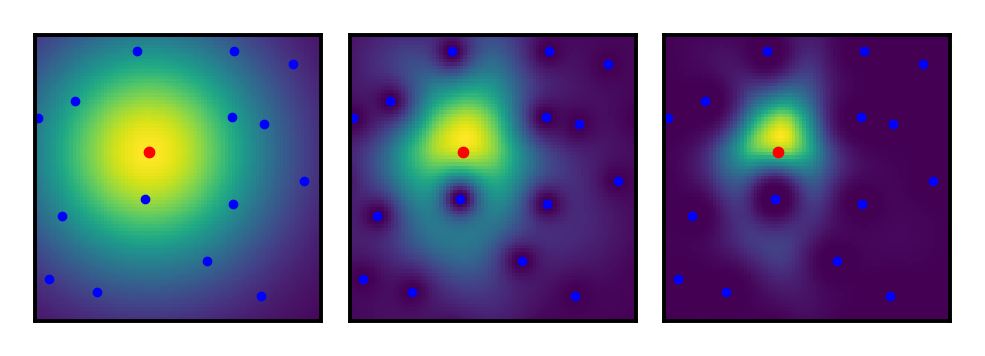

In [326]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(aps_halfwidth, 1.3 * (n_points // row) * aps_halfwidth / row),
    dpi=350,
)
for a in ax.flatten():
    a.set_xticks([])
    a.set_yticks([])
    a.set_aspect("equal")
    a.set_xlim([0, 1])
    a.set_ylim([0, 1])


ax[0].scatter(*p.T, s=1, color="b")
ax[1].scatter(*p.T, s=1, color="b")
ax[2].scatter(*p.T, s=1, color="b")

n = 9
res = 200
cm = "viridis"

ax[0].scatter(*p[n], s=2, color="r")
ax[1].scatter(*p[n], s=2, color="r")
ax[2].scatter(*p[n], s=2, color="r")

_, _, positions_unlooped, prob_dist = point_movement(p, n, 0.3, 0, 1, 4, resolution=res)
ax[0].pcolormesh(
    positions_unlooped[0], positions_unlooped[1], prob_dist, cmap=cm, zorder=-1
)

_, _, positions_unlooped, prob_dist = point_movement(
    p, n, 0.3, 0.1, 1, 4, resolution=res
)
ax[1].pcolormesh(
    positions_unlooped[0], positions_unlooped[1], prob_dist, cmap=cm, zorder=-1
)

_, _, positions_unlooped, prob_dist = point_movement(
    p, n, 0.3, 0.3, 1, 4, resolution=res
)
ax[2].pcolormesh(
    positions_unlooped[0], positions_unlooped[1], prob_dist, cmap=cm, zorder=-1
)

fig.subplots_adjust(hspace=0.3, wspace=0.1)
plt.savefig("apx_probs.pdf", transparent=True)